In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [37]:
train_data=pd.read_csv("/content/fashion-mnist_train.csv")
test_data=pd.read_csv("/content/fashion-mnist_test.csv")

In [38]:
train_data.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
test_data.head(5)

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [40]:
x_train=train_data.drop('label',axis=1).values
x_train.shape

(60000, 784)

In [41]:
y_train=train_data['label'].values
y_train.shape

(60000,)

In [42]:
x_test=test_data.drop('label',axis=1).values
x_test.shape

(10000, 784)

In [43]:
y_test=test_data['label'].values
y_test.shape

(10000,)

In [44]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,Dense,MaxPooling2D,Flatten

In [45]:
x_train=x_train.astype('float32')/255.0
x_test=x_test.astype('float32')/255.0

In [46]:
model=Sequential()
model.add(Conv2D(128,kernel_size=(3,3)))

In [47]:
model.add(MaxPooling2D())

In [48]:
model.add(Flatten())

In [49]:
model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='softmax'))

In [50]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [51]:
x_train.shape

(60000, 784)

In [52]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [55]:
model.fit(x_train,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 64ms/step - accuracy: 0.9663 - loss: 0.0926
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 121s 64ms/step - accuracy: 0.9681 - loss: 0.0865
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 65ms/step - accuracy: 0.9739 - loss: 0.0701


In [56]:
y_pred=model.predict(x_test)
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9155 - loss: 0.3835


[0.38347187638282776, 0.9154999852180481]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Actual label is 3
Prediction label is 3
Correct Prediction


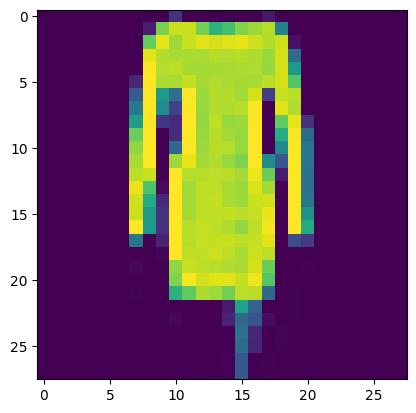

In [58]:
img_ind=4;
actual_label=y_test[img_ind]
prediction=model.predict(x_test[img_ind:img_ind+1])
prediction_label=np.argmax(prediction)
print(f"Actual label is {actual_label}")
print(f"Prediction label is {prediction_label}")
if(actual_label==prediction_label):
  print("Correct Prediction")
else:
  print("Incorrect Prediction")
plt.imshow(x_test[img_ind])